# AI Pipeline: NutriFirst Project

Notebook ini memuat tahapan mendetail (*end-to-end*) dalam membangun arsitektur model AI untuk Rekomendasi Gizi.

## 1. Import Library & Persiapan Lingkungan

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, confusion_matrix, classification_report, accuracy_score
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Layer, Dropout, BatchNormalization, Add
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
from sklearn.model_selection import train_test_split

# Setting tema visualisasi
sns.set_theme(style="darkgrid", palette="pastel")
print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.15.1


## 2. Pemuatan Data dan Eksplorasi (EDA)

In [76]:
print('Memuat dataset...')
df = pd.read_csv('../nutrition_with_price.csv')
display(df.head())

features = ['calories', 'proteins', 'fat', 'carbohydrate', 'harga']
df_features = df[features].copy()


Memuat dataset...


,id,calories,proteins,fat,carbohydrate,name,image,harga
0,1,280.0,9.2,28.4,0.0,Abon,https://img-cdn.medkomtek.com/PbrY9X3ignQ8sVuj...,33832
1,2,513.0,23.7,37.0,21.3,Abon haruwan,https://img-global.cpcdn.com/recipes/cbf330fbd...,21170
2,3,0.0,0.0,0.2,0.0,Agar-agar,https://res.cloudinary.com/dk0z4ums3/image/upl...,11616
3,4,45.0,1.1,0.4,10.8,Akar tonjong segar,https://images.tokopedia.net/img/cache/200-squ...,5272
4,5,37.0,4.4,0.5,3.8,Aletoge segar,https://nilaigizi.com/assets/images/produk/pro...,9703


## 3. Feature Engineering: Target Nutrition Score
Memformulasikan skor nutrisi berdasarkan parameter klinis.

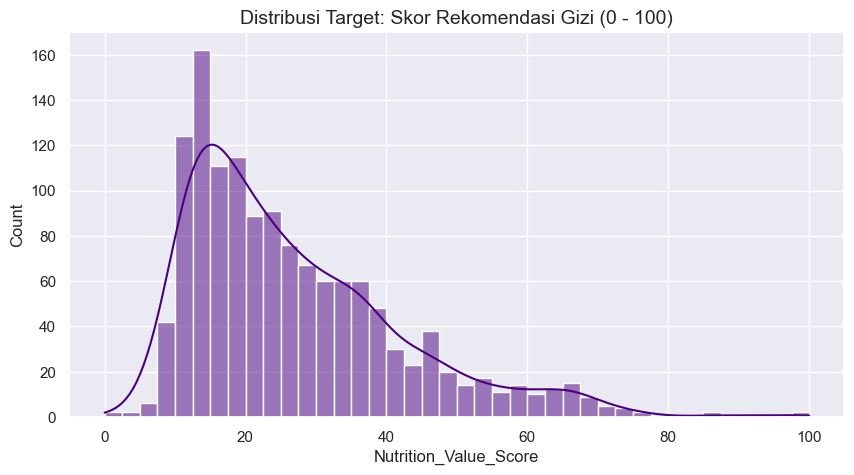

In [77]:
scaler_temp = MinMaxScaler()
df_normalized = pd.DataFrame(scaler_temp.fit_transform(df_features), columns=features)


raw_score = (
    (df_normalized['proteins'] * 0.4) +       # Protein sangat penting (40%)
    (df_normalized['calories'] * 0.3) +       # Kalori penting untuk energi (30%)
    (df_normalized['carbohydrate'] * 0.1) +   # Karbohidrat sebagai tenaga (10%)
    (df_normalized['fat'] * 0.1) -            # Lemak (10%)
    (df_normalized['harga'] * 0.1)            # Penalti harga diturunkan (-10%)
)

scaler_score = MinMaxScaler(feature_range=(0, 100))
df['Nutrition_Value_Score'] = scaler_score.fit_transform(raw_score.values.reshape(-1, 1))

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df['Nutrition_Value_Score'], bins=40, kde=True, color='indigo', ax=ax)
ax.set_title('Distribusi Target: Skor Rekomendasi Gizi (0 - 100)', fontsize=14)
plt.show()


## 4. Pemisahan Data Lanjutan (Train, Validation, Test Split)
Membagi data ke dalam 3 bagian secara independen untuk mencegah kebocoran data (*data leakage*):
- **Train (70%)**: Untuk melatih model.
- **Validation (15%)**: Untuk mengukur akurasi selama pelatihan berjalan & evaluasi early stopping.
- **Test (15%)**: Data buta (*unseen data*) murni untuk pengetesan akhir akurasi asli model.

In [78]:
scaler_nn = MinMaxScaler()
X = scaler_nn.fit_transform(df_features)
y = df['Nutrition_Value_Score'].values

# Tahap 1: Memisahkan Train Data dengan sisa data (Val + Test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)

# Tahap 2: Membagi sisa data secara rata menjadi Validation & Test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print("===== DISTRIBUSI DATASET =====")
print(f"Jumlah data Training   : {X_train.shape[0]} (70%)")
print(f"Jumlah data Validation : {X_val.shape[0]} (15%)")
print(f"Jumlah data Testing    : {X_test.shape[0]} (15%)")


===== DISTRIBUSI DATASET =====
Jumlah data Training   : 942 (70%)
Jumlah data Validation : 202 (15%)
Jumlah data Testing    : 202 (15%)


## 5. Pembuatan Komponen Deep Learning Kustom
Membangun *Custom Dense Layer* dan *Custom Callback* untuk memonitor laju loss.

In [79]:
class CustomDenseLayer(Layer):
    def __init__(self, units, activation=None, **kwargs):
        super(CustomDenseLayer, self).__init__(**kwargs)
        self.units = units
        self.activation = tf.keras.activations.get(activation)

    def build(self, input_shape):
        self.w = self.add_weight(shape=(input_shape[-1], self.units), initializer='he_normal', trainable=True, name='kernel')
        self.b = self.add_weight(shape=(self.units,), initializer='zeros', trainable=True, name='bias')
        super(CustomDenseLayer, self).build(input_shape)

    def call(self, inputs):
        output = tf.matmul(inputs, self.w) + self.b
        if self.activation is not None:
            output = self.activation(output)
        return output

class MonitorCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1:03d} -> Loss: {logs.get('loss'):.4f}, MAE: {logs.get('mae'):.4f}, Val_Loss: {logs.get('val_loss'):.4f}, Val_MAE: {logs.get('val_mae'):.4f}")


## 6. Desain Arsitektur Deep Network (ResNet-Style)
Arsitektur canggih dengan penambahan blok Residual (*Skip Connection*), Dropout, dan Batch Normalization agar model tidak mengalami *Vanishing Gradient* selama proses pembelajaran yang panjang.

In [80]:
inputs = Input(shape=(X_train.shape[1],), name='input_features')

# Layer Kustom Pertama
x = CustomDenseLayer(128, activation='relu', name='custom_dense_1')(inputs)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)

# Blok Residual (Skip Connection)
res_input = Dense(64, activation='relu')(x)
x1 = Dense(64, activation='relu', kernel_regularizer=l2(0.01))(res_input)
x1 = BatchNormalization()(x1)
x2 = Dense(64, activation='relu', kernel_regularizer=l2(0.01))(x1)
x2 = BatchNormalization()(x2)
skip = Add()([res_input, x2])  # Menambahkan input sebelumnya ke output
x = Dropout(0.2)(skip)

# Ekstraksi Fitur Final
x = Dense(32, activation='relu')(x)
outputs = Dense(1, name='output_prediction')(x)

model = Model(inputs=inputs, outputs=outputs, name='NutriScorer')
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

model.summary()


Model: "NutriScorer"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_features (InputLayer  [(None, 5)]                  0         []                            
 )                                                                                                
                                                                                                  
 custom_dense_1 (CustomDens  (None, 128)                  768       ['input_features[0][0]']      
 eLayer)                                                                                          
                                                                                                  
 batch_normalization_15 (Ba  (None, 128)                  512       ['custom_dense_1[0][0]']      
 tchNormalization)                                                                      

## 7. Proses Training Model dengan Validation Set
Melatih model secara mendalam dengan *Early Stopping* untuk mencegah overfitting. Training di-set untuk memproses `verbose=1` agar kemajuan per Epoch dapat dimonitor secara langsung.

In [81]:
import datetime
import os
from tensorflow.keras.callbacks import TensorBoard

print('Memulai proses training (Training & Validation)...')

# --- TAMBAHAN SIDE QUEST: TENSORBOARD ---
log_dir = os.path.join("logs", "fit", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

# Inisialisasi callback kustom kita (Ini yang tadi terhapus!)
monitor_callback = MonitorCallback()

# Training model menggunakan data latih dan evaluasi pada data validasi
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[monitor_callback, tensorboard_callback], 
    verbose=0
)

print('Proses training beserta Log TensorBoard selesai dicetak!')


Memulai proses training (Training & Validation)...
Epoch 020 -> Loss: 19.4183, MAE: 3.0491, Val_Loss: 5.2897, Val_MAE: 1.1842
Epoch 040 -> Loss: 14.7518, MAE: 2.7271, Val_Loss: 3.8613, Val_MAE: 0.9939
Epoch 060 -> Loss: 13.4868, MAE: 2.6120, Val_Loss: 2.9079, Val_MAE: 1.0578
Epoch 080 -> Loss: 12.0834, MAE: 2.4255, Val_Loss: 2.5390, Val_MAE: 0.8085
Epoch 100 -> Loss: 10.9324, MAE: 2.2699, Val_Loss: 2.5323, Val_MAE: 0.6951
Proses training beserta Log TensorBoard selesai dicetak!


## 8. Kurva Pembelajaran & Garis Evaluasi Final Test
Menampilkan kurva dinamis Train vs Val. Selain itu, kita memasukkan Garis Putus-putus Evaluasi Test Akhir untuk membuktikan bahwa akurasi Validasi sesuai dengan hasil nyata (Test).

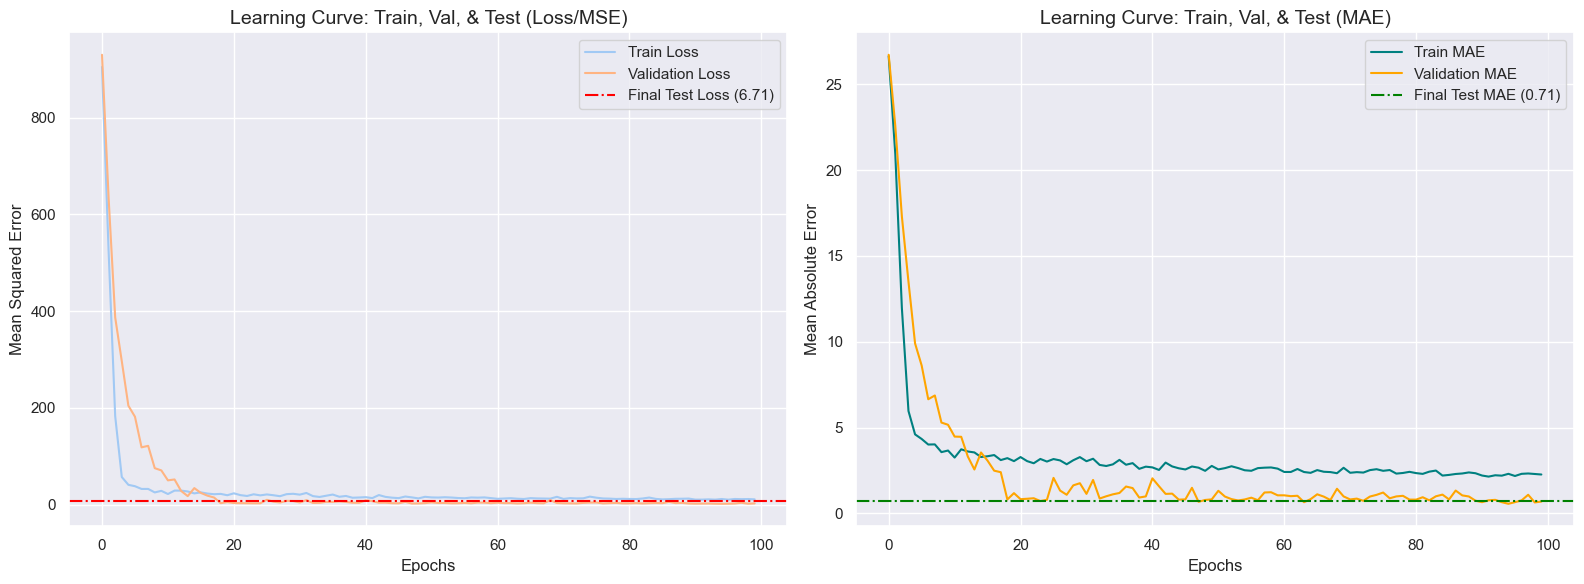

In [82]:
# Mengevaluasi data test murni (unseen data) terlebih dahulu
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Kurva MSE
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].axhline(test_loss, color='red', linestyle='-.', label=f'Final Test Loss ({test_loss:.2f})')
axes[0].set_title('Learning Curve: Train, Val, & Test (Loss/MSE)', fontsize=14)
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Mean Squared Error')
axes[0].legend()
axes[0].grid(True)

# Kurva MAE
axes[1].plot(history.history['mae'], label='Train MAE', color='teal')
axes[1].plot(history.history['val_mae'], label='Validation MAE', color='orange')
axes[1].axhline(test_mae, color='green', linestyle='-.', label=f'Final Test MAE ({test_mae:.2f})')
axes[1].set_title('Learning Curve: Train, Val, & Test (MAE)', fontsize=14)
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Mean Absolute Error')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


## 9. Evaluasi Regresi Utama (Pada Data Test)
Menghitung seberapa dekat skor prediksi dengan skor aktual menggunakan dataset Test yang sama sekali belum dilihat model.

In [83]:
y_pred_test = model.predict(X_test).flatten()

mae_score = mean_absolute_error(y_test, y_pred_test)
rmse_score = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2 = r2_score(y_test, y_pred_test)

print("="*50)
print("LAPORAN EVALUASI REGRESI (DATA TEST)")
print("="*50)
print(f"Mean Absolute Error (MAE) : {mae_score:.4f}")
print(f"Root Mean Squared Error   : {rmse_score:.4f}")
print(f"R-Squared (Kecocokan Model): {r2*100:.2f}%\n")


7/7 [==============================] - 0s 1ms/step
LAPORAN EVALUASI REGRESI (DATA TEST)
Mean Absolute Error (MAE) : 0.7063
Root Mean Squared Error   : 2.3598
R-Squared (Kecocokan Model): 97.73%



## 10. Analisis Sebaran Prediksi
Melihat pola kepadatan prediksi (KDE Jointplot) dan sebaran Residual (Residual Plot) pada data Test.

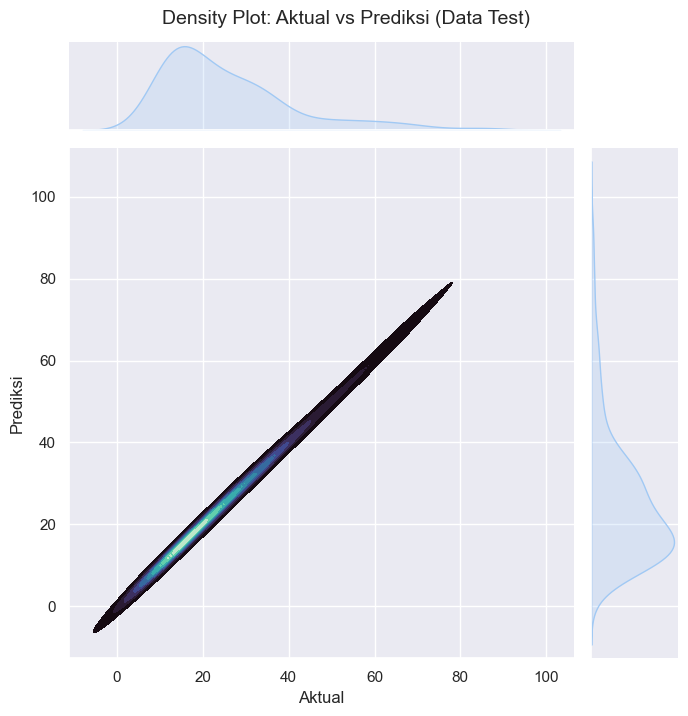

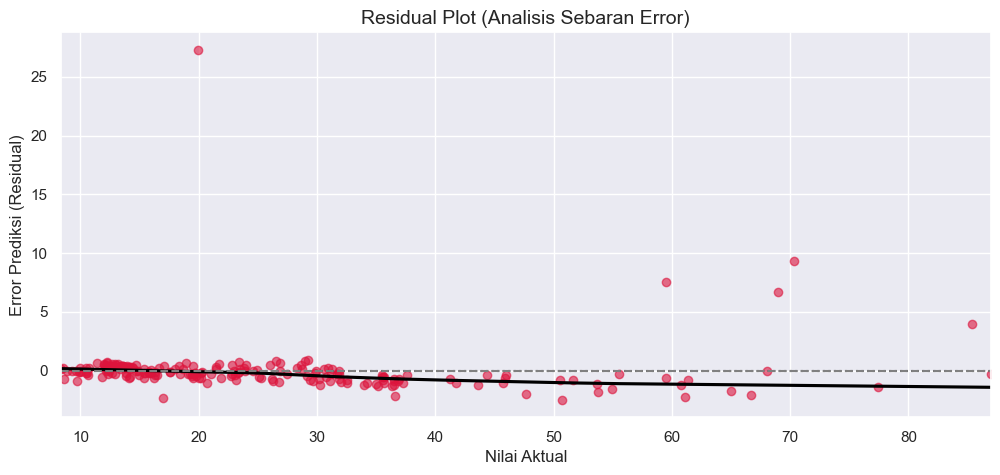

In [84]:
df_eval = pd.DataFrame({'Aktual': y_test, 'Prediksi': y_pred_test})
g = sns.jointplot(data=df_eval, x='Aktual', y='Prediksi', kind='kde', fill=True, cmap='mako', height=7)
g.fig.suptitle('Density Plot: Aktual vs Prediksi (Data Test)', y=1.02, fontsize=14)
plt.show()

plt.figure(figsize=(12, 5))
sns.residplot(x=y_test, y=y_pred_test, lowess=True, color='crimson', scatter_kws={'alpha': 0.6}, line_kws={'color': 'black'})
plt.title('Residual Plot (Analisis Sebaran Error)', fontsize=14)
plt.xlabel('Nilai Aktual')
plt.ylabel('Error Prediksi (Residual)')
plt.axhline(0, color='grey', linestyle='--')
plt.show()


## 11. Transformasi Klasifikasi & Akurasi Final
Mengubah prediksi regresi ke 4 tingkat kelas kelayakan gizi dan menghitung nilai akurasi klasifikasi secara matematis.

In [85]:
def map_to_class(score):
    if score <= 25: return '1. Tidak Layak'
    elif score <= 50: return '2. Kurang Layak'
    elif score <= 75: return '3. Layak'
    else: return '4. Sangat Layak'

y_test_cat = [map_to_class(s) for s in y_test]
y_pred_cat = [map_to_class(s) for s in y_pred_test]

accuracy = accuracy_score(y_test_cat, y_pred_cat)
print("="*50)
print(f"AKURASI KLASIFIKASI FINAL (DATA TEST): {accuracy * 100:.2f}%")
print("="*50)


AKURASI KLASIFIKASI FINAL (DATA TEST): 96.53%


## 12. Laporan Klasifikasi & Confusion Matrix
Detail performa Precision, Recall, dan persebaran prediksi kelas.

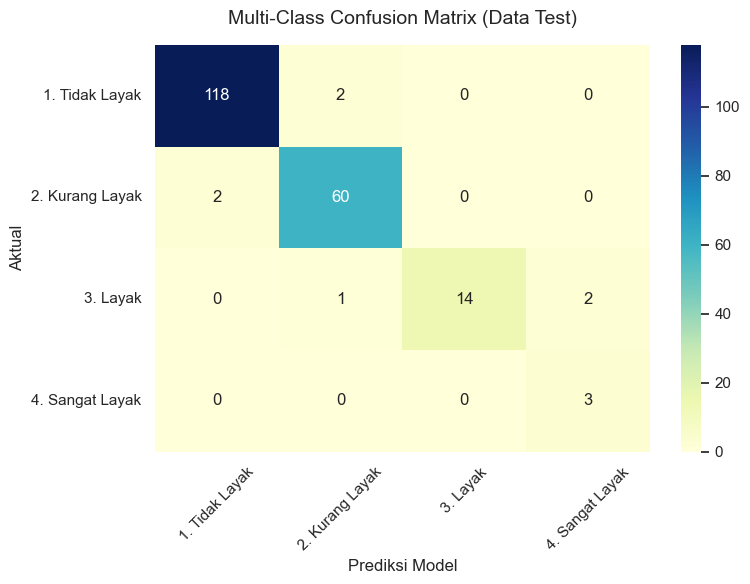


CLASSIFICATION REPORT
--------------------------------------------------
                 precision    recall  f1-score   support

 1. Tidak Layak       0.98      0.98      0.98       120
2. Kurang Layak       0.95      0.97      0.96        62
       3. Layak       1.00      0.82      0.90        17
4. Sangat Layak       0.60      1.00      0.75         3

       accuracy                           0.97       202
      macro avg       0.88      0.94      0.90       202
   weighted avg       0.97      0.97      0.97       202



In [86]:
labels = ['1. Tidak Layak', '2. Kurang Layak', '3. Layak', '4. Sangat Layak']
cm = confusion_matrix(y_test_cat, y_pred_cat, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', xticklabels=labels, yticklabels=labels)
plt.title('Multi-Class Confusion Matrix (Data Test)', fontsize=14, pad=15)
plt.xlabel('Prediksi Model')
plt.ylabel('Aktual')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nCLASSIFICATION REPORT")
print("-"*50)
print(classification_report(y_test_cat, y_pred_cat, labels=labels, zero_division=0))


## 13. Feature Importance (Bobot Dense Layer Kustom)
Melihat nilai absolut matriks bobot di layer pertama untuk mengetahui nutrisi apa yang paling dipertimbangkan model.

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_8752\361909839.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_importance, x='Kepentingan', y='Fitur', palette='viridis')


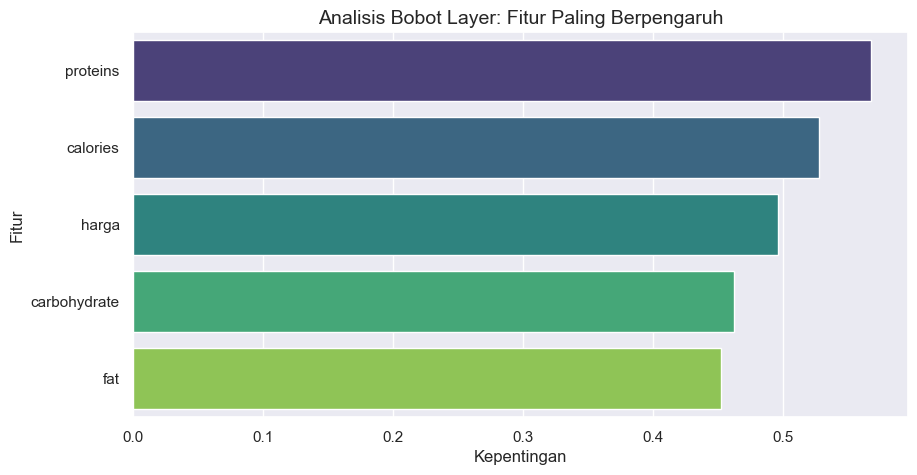

In [87]:
custom_layer = model.get_layer('custom_dense_1')
weights = custom_layer.get_weights()[0]

feature_importance = np.mean(np.abs(weights), axis=1)
df_importance = pd.DataFrame({
    'Fitur': features,
    'Kepentingan': feature_importance
}).sort_values(by='Kepentingan', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=df_importance, x='Kepentingan', y='Fitur', palette='viridis')
plt.title('Analisis Bobot Layer: Fitur Paling Berpengaruh', fontsize=14)
plt.show()


## 14. Explainable AI (XAI) dengan SHAP
Menggunakan SHAP (SHapley Additive exPlanations) untuk memahami kontribusi masing-masing fitur nutrisi secara mendetail terhadap prediksi model. Ini adalah standar riset akademik untuk menjelaskan keputusan Black-Box AI.

c:\Users\Lenovo\miniconda3\envs\dcdenv\lib\site-packages\shap\explainers\_deep\deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
c:\Users\Lenovo\miniconda3\envs\dcdenv\lib\site-packages\keras\src\backend.py:452: UserWarning: `tf.keras.backend.set_learning_phase` is deprecated and will be removed after 2020-10-11. To update it, simply pass a True/False value to the `training` argument of the `__call__` method of your layer or model.
  warnings.warn(


Menghitung nilai SHAP (membutuhkan sedikit waktu)...

--- SHAP Summary Plot ---
Plot ini menunjukkan fitur mana yang paling mempengaruhi model untuk menaikkan atau menurunkan skor kelayakan.


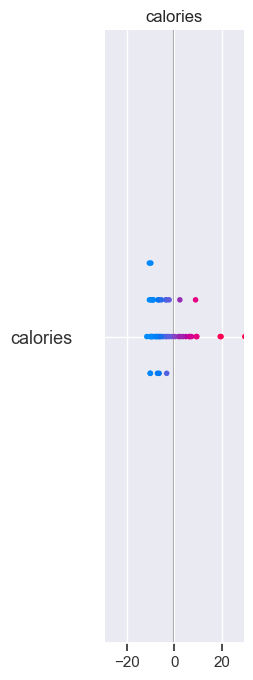

In [88]:
import shap
shap.initjs()

print("Menghitung nilai SHAP (membutuhkan sedikit waktu)...")
# Menggunakan GradientExplainer atau DeepExplainer
# Mengingat ini adalah model Keras standar, kita bisa menggunakan DeepExplainer dengan subset background
background = X_train[:100] # Ambil 100 sampel sebagai baseline
explainer = shap.DeepExplainer(model, background)

# Menghitung SHAP value untuk 50 sampel data test
shap_values = explainer.shap_values(X_test[:50])

print("\n--- SHAP Summary Plot ---")
print("Plot ini menunjukkan fitur mana yang paling mempengaruhi model untuk menaikkan atau menurunkan skor kelayakan.")
# Menggambar visualisasi SHAP beeswarm plot
shap.summary_plot(shap_values, X_test[:50], feature_names=features)


## 15. Detailed Error Analysis (Analisis Kasus Ekstrem)
Melihat 5 makanan dengan prediksi yang paling meleset (Error absolut terbesar) untuk memahami kelemahan atau kebingungan model saat ini.

In [89]:
import pandas as pd
import numpy as np
from IPython.display import display

# Menghitung selisih absolut antara aktual regresi dan prediksi regresi
errors = np.abs(y_test - y_pred_test)

# Membalikkan scaling untuk melihat nilai gizi asli menggunakan scaler yang tadi (scaler_nn)
X_test_original = scaler_nn.inverse_transform(X_test)

# Membuat DataFrame khusus untuk analisis error
error_df = pd.DataFrame(X_test_original, columns=features)

# Membulatkan fitur agar enak dibaca
for col in features:
    error_df[col] = error_df[col].round(2)

error_df['Aktual_Score'] = np.round(y_test, 2)
error_df['Prediksi_Score'] = np.round(y_pred_test, 2)
error_df['Error_Absolut'] = np.round(errors, 2)

# Memasukkan label kategorinya agar lebih deskriptif
error_df['Aktual_Kategori'] = y_test_cat
error_df['Prediksi_Kategori'] = y_pred_cat

# Mengambil 5 prediksi dengan error paling tinggi
top_errors = error_df.sort_values(by='Error_Absolut', ascending=False).head(5)

print("=== 5 KASUS DENGAN ERROR TERTINGGI (PREDIKSI PALING MELESET) ===\n")
display(top_errors)

print("\nInterpretasi Analisis Error:")
print("Tabel di atas menunjukkan makanan yang ditebak dengan error terbesar oleh model di Test Set.")
print("Biasanya hal ini terjadi karena adanya data anomali (outlier), misalnya makanan yang sangat murah")
print("tetapi gizinya ekstrem, sehingga membingungkan AI. Memahami pola error ini sangat krusial")
print("bagi Data Scientist untuk improvisasi iterasi model berikutnya.")


=== 5 KASUS DENGAN ERROR TERTINGGI (PREDIKSI PALING MELESET) ===



,calories,proteins,fat,carbohydrate,harga,Aktual_Score,Prediksi_Score,Error_Absolut,Aktual_Kategori,Prediksi_Kategori
167,60.0,1.0,60.0,13.0,11022.0,19.90,47.310001,27.40,1. Tidak Layak,2. Kurang Layak
177,902.0,0.0,100.0,0.0,5255.0,70.30,81.449997,11.15,3. Layak,4. Sangat Layak
160,725.0,0.5,81.6,1.4,4012.0,59.52,68.529999,9.01,3. Layak,3. Layak
45,902.0,0.0,100.0,0.0,7946.0,68.99,77.500000,8.51,3. Layak,4. Sangat Layak
116,588.0,53.7,40.9,1.2,6519.0,85.40,91.699997,6.31,4. Sangat Layak,4. Sangat Layak



Interpretasi Analisis Error:
Tabel di atas menunjukkan makanan yang ditebak dengan error terbesar oleh model di Test Set.
Biasanya hal ini terjadi karena adanya data anomali (outlier), misalnya makanan yang sangat murah
tetapi gizinya ekstrem, sehingga membingungkan AI. Memahami pola error ini sangat krusial
bagi Data Scientist untuk improvisasi iterasi model berikutnya.


## 16. Ekspor Model
Menyimpan model ke dalam format Keras/SavedModel.

In [90]:
import joblib
model.save('nutri_model.keras')
model.export('saved_model/nutri_model')
joblib.dump(scaler_nn, 'scaler_nn.pkl')
print('Scaler berhasil diekspor sebagai scaler_nn.pkl!')
print('\nModel berhasil diekspor dan siap diintegrasikan dengan API!')


INFO:tensorflow:Assets written to: saved_model/nutri_model\assets


INFO:tensorflow:Assets written to: saved_model/nutri_model\assets


Saved artifact at 'saved_model/nutri_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 5), dtype=tf.float32, name='input_features')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  1749871890496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1749871894368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1749871915600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1749871918064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1749871917712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1749871915072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1750113974928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1750113974400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1750114007696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1750114005232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1749835346160: TensorSpec(shape=(),

## 17. Contoh Proses Inference Model (Tugas Main Quest)
Bagian ini mendemonstrasikan bagaimana memuat (load) model yang telah diekspor dan menggunakannya untuk memprediksi data makanan baru.

In [91]:
import tensorflow as tf
import numpy as np

# 1. Load model yang sudah disave di tahap sebelumnya
loaded_model = tf.keras.models.load_model('nutri_model.keras', custom_objects={'CustomDenseLayer': CustomDenseLayer})

# 2. Contoh data makanan baru
# (Misal: Calories=200, Proteins=10, Fat=5, Carbohydrate=20, Harga=15000)
# Urutan fitur: ['calories', 'proteins', 'fat', 'carbohydrate', 'harga']
data_baru = np.array([[200, 10, 5, 20, 15000]])

# 3. Normalisasi data baru menggunakan scaler_nn yang sudah di-fit saat training
data_baru_scaled = scaler_nn.transform(data_baru)

# 4. Lakukan Prediksi
prediksi_skor = loaded_model.predict(data_baru_scaled)[0][0]

# 5. Konversi skor ke kelas kelayakan menggunakan fungsi map_to_class yang sudah dibuat
hasil_kelas = map_to_class(prediksi_skor)

print("="*50)
print("🍽️ HASIL INFERENCE MAKANAN BARU 🍽️")
print("="*50)
print(f"Skor Kelayakan (Regresi) : {prediksi_skor:.2f}")
print(f"Kategori Kelayakan       : {hasil_kelas}")
print("="*50)


1/1 [==============================] - 0s 113ms/step
🍽️ HASIL INFERENCE MAKANAN BARU 🍽️
Skor Kelayakan (Regresi) : 23.79
Kategori Kelayakan       : 1. Tidak Layak


c:\Users\Lenovo\miniconda3\envs\dcdenv\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
